In [1]:
import zipfile
import os

# Extract archive.zip
with zipfile.ZipFile('/content/archive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

# Find the extracted folder (usually 'asl_dataset' or similar)
extracted = [d for d in os.listdir('/content/')
             if os.path.isdir(os.path.join('/content/', d))
             and d not in ['.config', 'sample_data', '__MACOSX']]

print("Extracted folders:", extracted)

# Set the dataset path
DATASET_DIR = os.path.join('/content/', extracted[0]) if extracted else '/content/asl_dataset'
print(f"Dataset path: {DATASET_DIR}")
print(f"Classes: {sorted(os.listdir(DATASET_DIR))[:10]}...")

Extracted folders: ['asl_dataset']
Dataset path: /content/asl_dataset
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']...


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import cv2
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, TensorBoard
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: []


Total classes: 37
All classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'asl_dataset', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']

Total images: 2515
Min: 0, Max: 70, Avg: 68.0


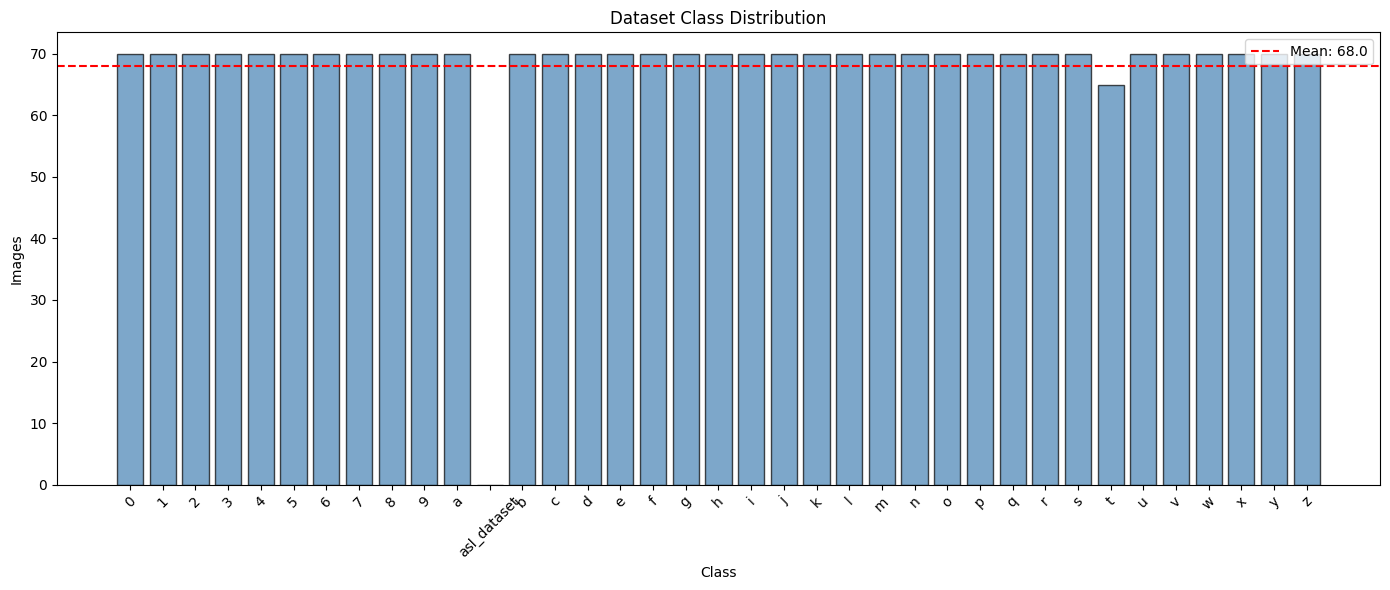

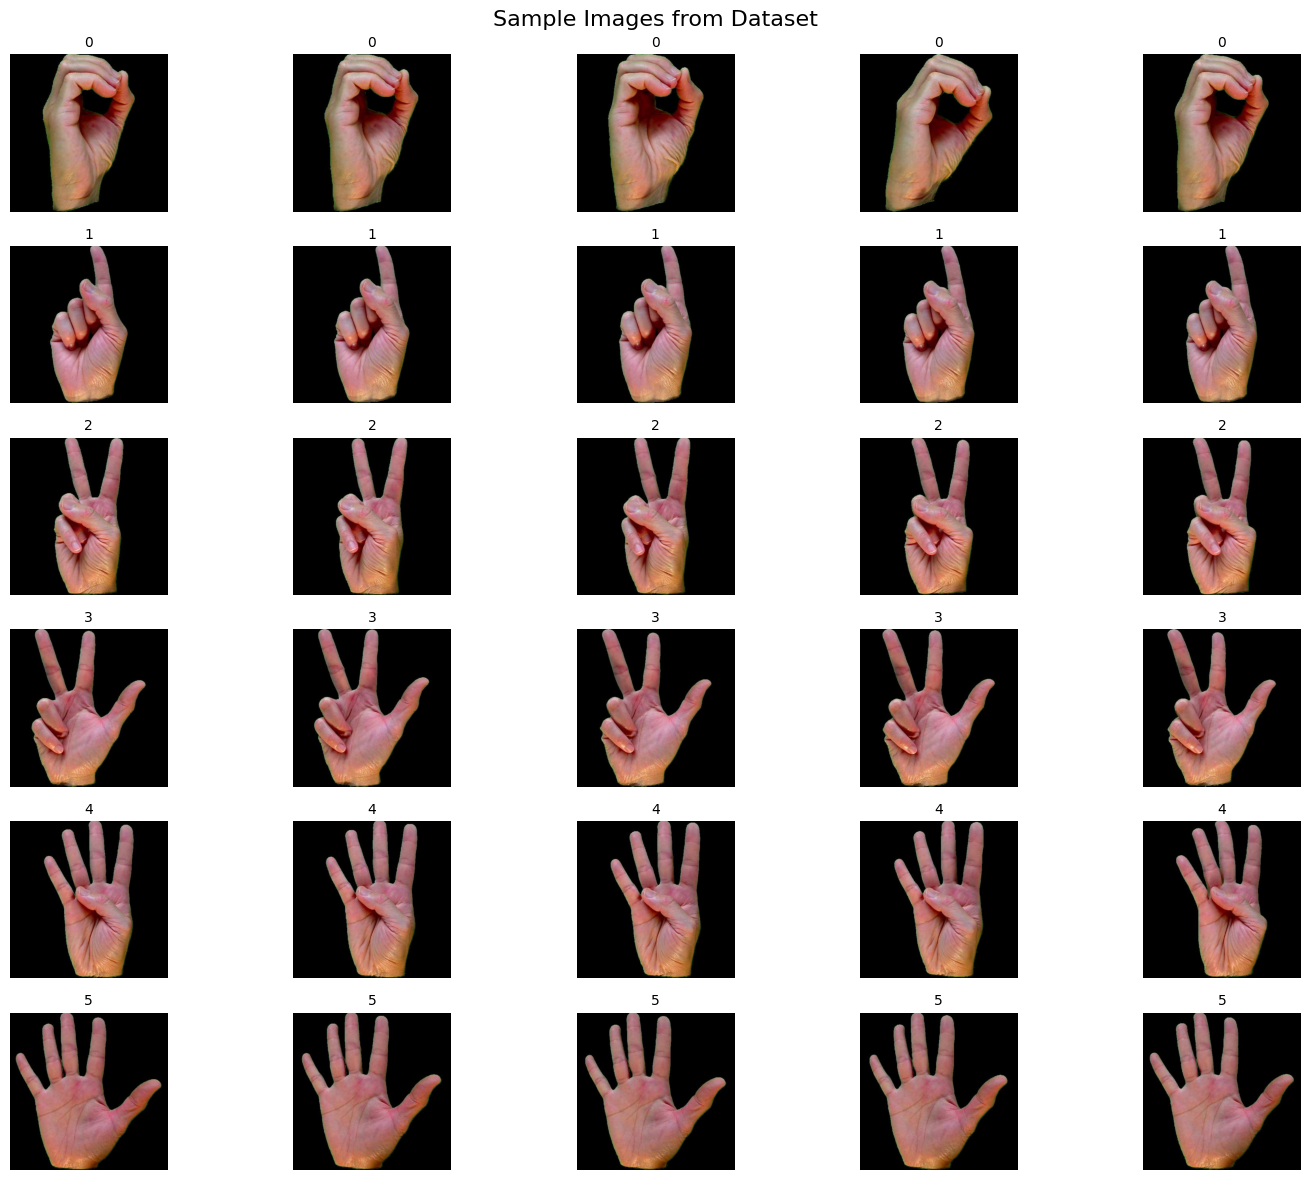

In [3]:
# Look at what we have
classes = sorted([d for d in os.listdir(DATASET_DIR)
                  if os.path.isdir(os.path.join(DATASET_DIR, d))])
print(f"Total classes: {len(classes)}")
print(f"All classes: {classes}")

# Count images per class
class_counts = {}
for c in classes:
    imgs = [f for f in os.listdir(os.path.join(DATASET_DIR, c))
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    class_counts[c] = len(imgs)

total = sum(class_counts.values())
print(f"\nTotal images: {total}")
print(f"Min: {min(class_counts.values())}, Max: {max(class_counts.values())}, Avg: {np.mean(list(class_counts.values())):.1f}")

# Plot distribution
plt.figure(figsize=(14, 6))
plt.bar(class_counts.keys(), class_counts.values(), color='steelblue', edgecolor='black', alpha=0.7)
plt.axhline(y=np.mean(list(class_counts.values())), color='r', linestyle='--', label=f"Mean: {np.mean(list(class_counts.values())):.1f}")
plt.xlabel('Class'); plt.ylabel('Images'); plt.title('Dataset Class Distribution')
plt.xticks(rotation=45); plt.legend(); plt.tight_layout()
plt.show()

# Show sample images
fig, axes = plt.subplots(min(6, len(classes)), 5, figsize=(15, 12))
fig.suptitle('Sample Images from Dataset', fontsize=16)
if len(classes[:6]) == 1: axes = np.array([axes])

for i, c in enumerate(classes[:6]):
    imgs = sorted([f for f in os.listdir(os.path.join(DATASET_DIR, c))
                   if f.lower().endswith(('.png', '.jpg', '.jpeg'))])[:5]
    for j, img_name in enumerate(imgs):
        img = cv2.cvtColor(cv2.imread(os.path.join(DATASET_DIR, c, img_name)), cv2.COLOR_BGR2RGB)
        axes[i, j].imshow(img)
        axes[i, j].set_title(c, fontsize=10)
        axes[i, j].axis('off')
plt.tight_layout(); plt.show()

In [14]:
IMG_SIZE = 224
BATCH_SIZE = 32

# Get all file paths and labels
file_paths = []
labels = []
class_to_idx = {name: idx for idx, name in enumerate(classes)}

for c in classes:
    for f in os.listdir(os.path.join(DATASET_DIR, c)):
        if f.lower().endswith(('.png', '.jpg', '.jpeg')):
            file_paths.append(os.path.join(DATASET_DIR, c, f))
            labels.append(class_to_idx[c])

file_paths = np.array(file_paths)
labels = np.array(labels)
NUM_CLASSES = len(classes)

print(f"Total samples: {len(file_paths)}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Label range: {min(labels)} to {max(labels)}")
print(f"Unique labels: {sorted(set(labels))}")

# Split
train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
    file_paths, labels, test_size=0.15, random_state=SEED, stratify=labels)

train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_val_paths, train_val_labels, test_size=0.176, random_state=SEED, stratify=train_val_labels)

print(f"Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")
print(f"Train unique labels: {sorted(set(train_labels))}")

# Compute class weights - FIX: ensure all classes are covered
unique_train = np.unique(train_labels)
class_weights = compute_class_weight(class_weight='balanced', classes=unique_train, y=train_labels)

# Build dict with ALL class indices, default 1.0 for missing
class_weight_dict = {i: 1.0 for i in range(NUM_CLASSES)}
for idx, cls in enumerate(unique_train):
    class_weight_dict[int(cls)] = float(class_weights[idx])

print(f"Class weight keys: {sorted(class_weight_dict.keys())}")
print("✓ Class weights computed")

# Preprocessing
def preprocess(path, label, augment=False):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])

    if augment:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, 0.1)
        img = tf.image.random_contrast(img, 0.9, 1.1)

    img = tf.cast(img, tf.float32) / 127.5 - 1.0
    label = tf.one_hot(label, depth=NUM_CLASSES)
    return img, label

AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = train_ds.map(lambda x, y: preprocess(x, y, True), num_parallel_calls=AUTOTUNE)
train_ds = train_ds.shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = val_ds.map(lambda x, y: preprocess(x, y, False), num_parallel_calls=AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = test_ds.map(lambda x, y: preprocess(x, y, False), num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

print("✓ Data pipeline ready")

Total samples: 2515
Number of classes: 37
Label range: 0 to 36
Unique labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36)]
Train: 1760 | Val: 377 | Test: 378
Train unique labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np

In [15]:
# Build MobileNetV2 model - use NUM_CLASSES from previous cell
base_model = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet', pooling=None)
base_model.trainable = False

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, use_bias=False)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)  # Use detected NUM_CLASSES

model = Model(inputs, outputs, name='Bridge_MobileNetV2')
model.summary()

print(f"\nTotal params: {model.count_params():,}")
print(f"Trainable params: {sum([keras.backend.count_params(w) for w in model.trainable_weights]):,}")
print(f"NUM_CLASSES: {NUM_CLASSES}")

Model: "Bridge_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 512)            │       655,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 37)             │         9,509 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,056,997 (11.66 MB)

 Trainable params: 797,477 (3.04 MB)

 Non-trainable params: 2,259,520 (8.62 MB)


Total params: 3,056,997
Trainable params: 797,477
NUM_CLASSES: 37


In [16]:
# Compile
model.compile(optimizer=Adam(learning_rate=1e-3),
              loss=CategoricalCrossentropy(label_smoothing=0.1),
              metrics=['accuracy'])

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    ModelCheckpoint('models/best.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

os.makedirs('models', exist_ok=True)

# Train - REMOVE class_weight parameter to avoid the error
print("\n=== PHASE 1: Training with frozen base ===")
history = model.fit(train_ds, epochs=10, validation_data=val_ds,
                    callbacks=callbacks, verbose=1)  # NO class_weight


=== PHASE 1: Training with frozen base ===
Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3282 - loss: 2.7757
Epoch 1: val_accuracy improved from None to 0.63130, saving model to models/best.keras

Epoch 1: finished saving model to models/best.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step - accuracy: 0.5312 - loss: 2.1178 - val_accuracy: 0.6313 - val_loss: 1.7334 - learning_rate: 0.0010
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8602 - loss: 1.1923
Epoch 2: val_accuracy improved from 0.63130 to 0.86472, saving model to models/best.keras

Epoch 2: finished saving model to models/best.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.8670 - loss: 1.1550 - val_accuracy: 0.8647 - val_loss: 1.2284 - learning_rate: 0.0010
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9203 - loss: 1.0123
Epoch 3: val_accuracy improved from 0.86472 to 0.88594, saving model to models/best.keras

Epoch 3: finished saving model to models/best.keras
5

In [17]:
# Unfreeze top 30 layers of base
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with lower learning rate
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss=CategoricalCrossentropy(label_smoothing=0.1),
              metrics=['accuracy'])

# Update checkpoint
callbacks[2] = ModelCheckpoint('models/best_finetuned.keras', monitor='val_accuracy', save_best_only=True, verbose=1)

print("\n=== PHASE 2: Fine-tuning ===")
fine_tune_history = model.fit(train_ds, epochs=50, initial_epoch=len(history.epoch),
                              validation_data=val_ds, callbacks=callbacks,
                              class_weight=class_weight_dict, verbose=1)

# Combine histories
for key in history.history:
    history.history[key].extend(fine_tune_history.history[key])


=== PHASE 2: Fine-tuning ===
Epoch 11/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5411 - loss: 2.0839
Epoch 11: val_accuracy improved from None to 0.95756, saving model to models/best_finetuned.keras

Epoch 11: finished saving model to models/best_finetuned.keras
55/55 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.6040 - loss: 1.9318 - val_accuracy: 0.9576 - val_loss: 0.8961 - learning_rate: 1.0000e-05
Epoch 12/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7411 - loss: 1.5961
Epoch 12: val_accuracy did not improve from 0.95756
55/55 ━━━━━━━━━━━━━━━━━━━━ 117s 2s/step - accuracy: 0.7614 - loss: 1.5190 - val_accuracy: 0.9178 - val_loss: 0.9915 - learning_rate: 1.0000e-05
Epoch 13/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8439 - loss: 1.2799
Epoch 13: val_accuracy did not improve from 0.95756
55/55 ━━━━━━━━━━━━━━━━━━━━ 116s 2s/step - accuracy: 0.8420 - loss: 1.2791 - val_accuracy: 0.8886 - val_loss: 1.0582 - learning_rate: 1.0000e-05
Epoch 14/50
55/55 ━━

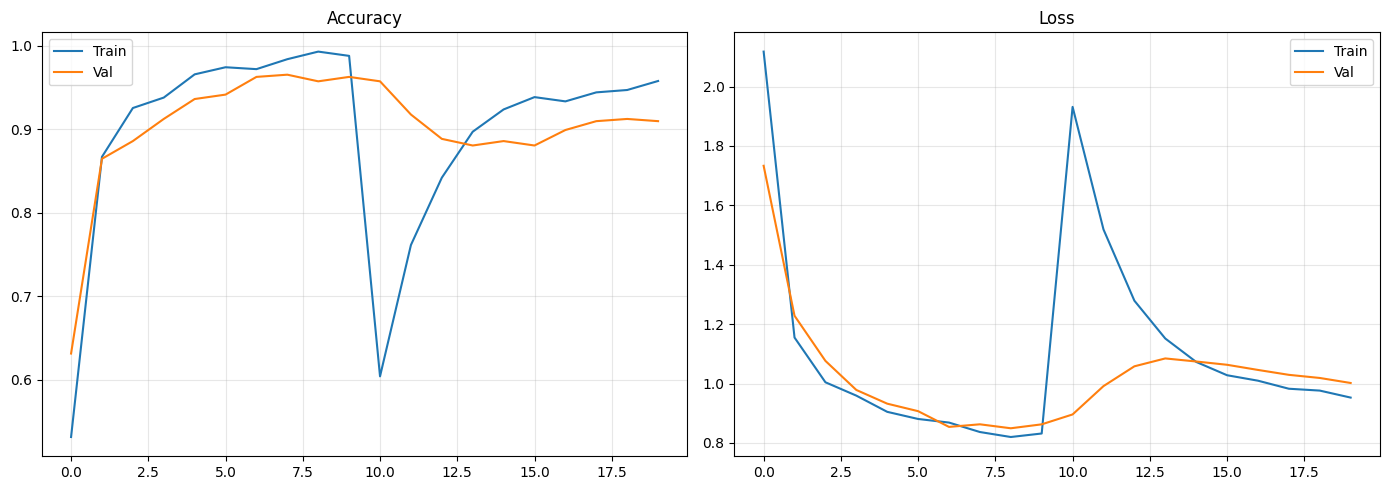

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step

TEST RESULTS
Accuracy:  0.9444 (94.44%)
Precision: 0.9534
Recall:    0.9444
F1-Score:  0.9431

Unique labels in test/predictions: 36 out of 37

Detailed Report (for present classes only):
              precision    recall  f1-score   support

           0       0.80      0.80      0.80        10
           1       1.00      1.00      1.00        11
           2       0.85      1.00      0.92        11
           3       1.00      1.00      1.00        11
           4       1.00      1.00      1.00        10
           5       1.00      1.00      1.00        10
           6       0.65      1.00      0.79        11
           7       0.92      1.00      0.96        11
           8       1.00      0.90      0.95        10
           9       1.00      1.00      1.00        10
           a       1.00      0.82      0.90        11
           b       1.00      1.00      1.00        11
           c       1.00      1.00      1.00        10
           d   

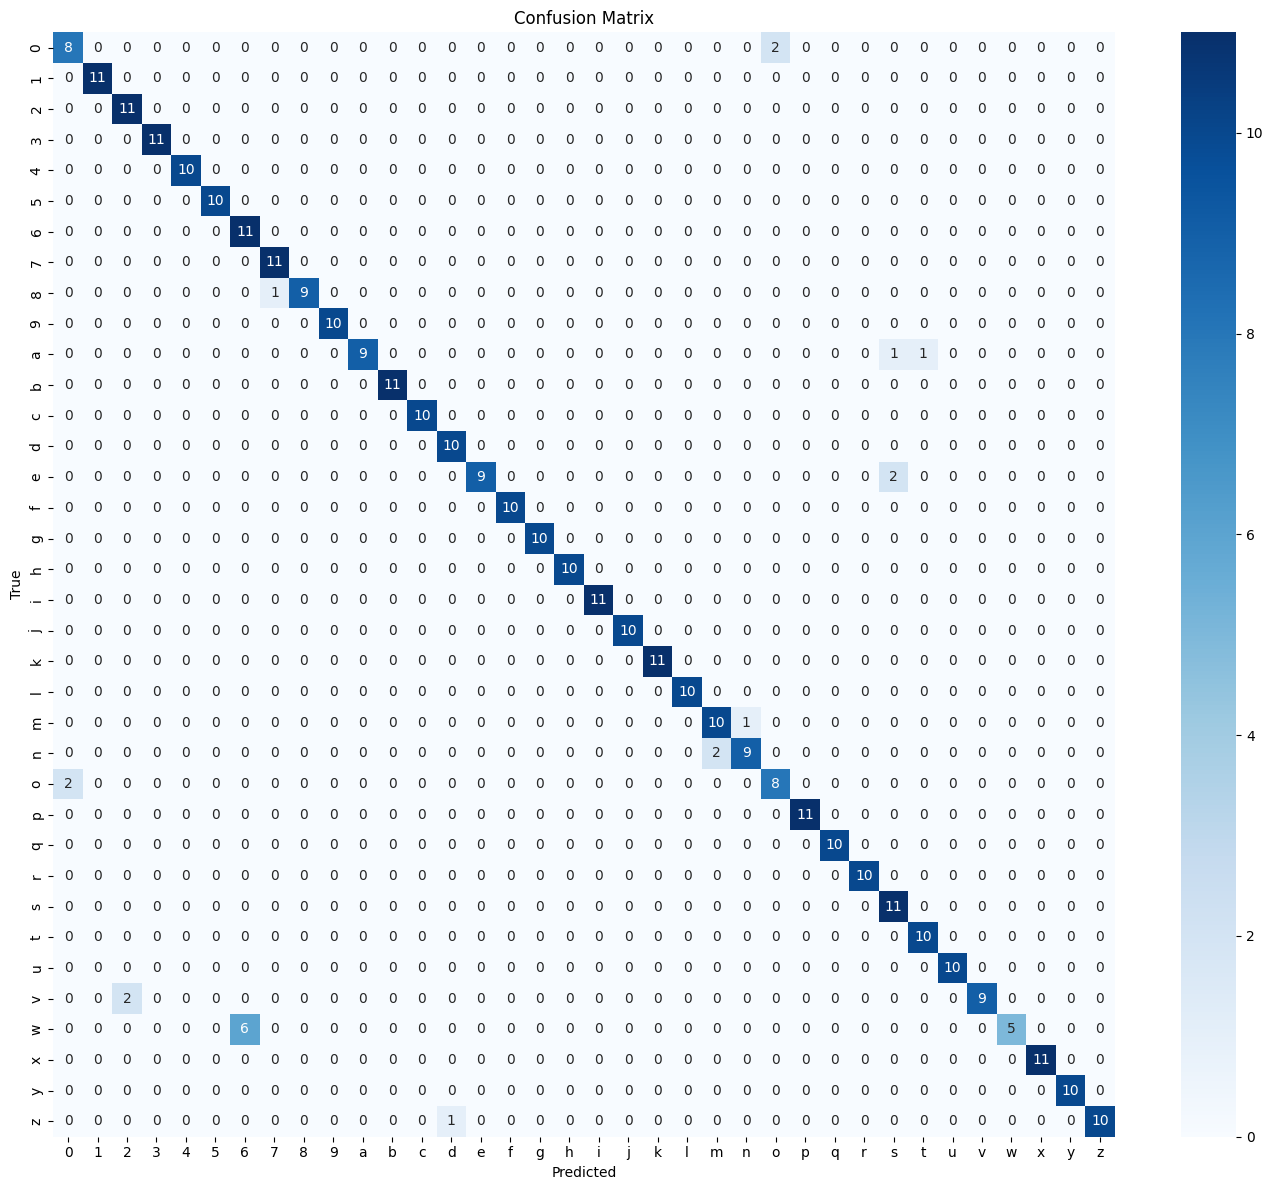

In [20]:
# Predict
predictions = model.predict(test_ds, verbose=1)
pred_labels = np.argmax(predictions, axis=1)

# Metrics
acc = accuracy_score(test_labels, pred_labels)
p, r, f1, _ = precision_recall_fscore_support(test_labels, pred_labels, average='weighted')

print(f"\n{'='*50}")
print(f"TEST RESULTS")
print(f"{'='*50}")
print(f"Accuracy:  {acc:.4f} ({acc*100:.2f}%)")
print(f"Precision: {p:.4f}")
print(f"Recall:    {r:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"{'='*50}")

# Find which labels actually appear
unique_labels = sorted(set(test_labels) | set(pred_labels))
print(f"\nUnique labels in test/predictions: {len(unique_labels)} out of {NUM_CLASSES}")

# FIX: Only pass target_names for labels that actually exist
present_class_names = [classes[i] for i in unique_labels]

print("\nDetailed Report (for present classes only):")
print(classification_report(test_labels, pred_labels,
                            target_names=present_class_names,
                            labels=unique_labels))

# Confusion matrix (only for present classes)
cm = confusion_matrix(test_labels, pred_labels, labels=unique_labels)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=present_class_names,
            yticklabels=present_class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

In [21]:
# Save model and classes
model.save('models/bridge_final_model.keras')
with open('models/class_names.pkl', 'wb') as f:
    pickle.dump(classes, f)

print("✓ Model saved to: models/bridge_final_model.keras")
print("✓ Classes saved to: models/class_names.pkl")

✓ Model saved to: models/bridge_final_model.keras
✓ Classes saved to: models/class_names.pkl


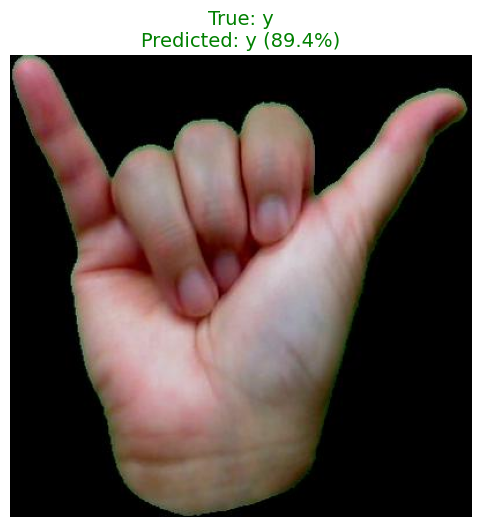

Top 5 predictions:
  y: 89.4%
  t: 1.0%
  l: 0.9%
  z: 0.7%
  8: 0.6%


In [23]:
# Pick a random test image
test_img_path = test_paths[0]
true_label = classes[test_labels[0]]

# Load and predict
img = cv2.cvtColor(cv2.imread(test_img_path), cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
img_norm = img_resized.astype(np.float32) / 127.5 - 1.0
img_batch = np.expand_dims(img_norm, 0)

pred = model.predict(img_batch, verbose=0)
pred_class = classes[np.argmax(pred[0])]
confidence = float(np.max(pred[0]))

# Show result
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.title(f"True: {true_label}\nPredicted: {pred_class} ({confidence*100:.1f}%)",
          color='green' if true_label == pred_class else 'red', fontsize=14)
plt.axis('off')
plt.show()

print(f"Top 5 predictions:")
top5 = np.argsort(pred[0])[-5:][::-1]
for i in top5:
    print(f"  {classes[i]}: {pred[0][i]*100:.1f}%")

In [24]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
backup_dir = '/content/drive/MyDrive/bridge_backup'
os.makedirs(backup_dir, exist_ok=True)

# Copy models folder
if os.path.exists('models'):
    shutil.copytree('models', f'{backup_dir}/models', dirs_exist_ok=True)
    print("✓ Saved to Google Drive!")

print(f"\nNext time, run this at the start:")
print(f"!cp -r /content/drive/MyDrive/bridge_backup/models /content/")

MessageError: Error: credential propagation was unsuccessful

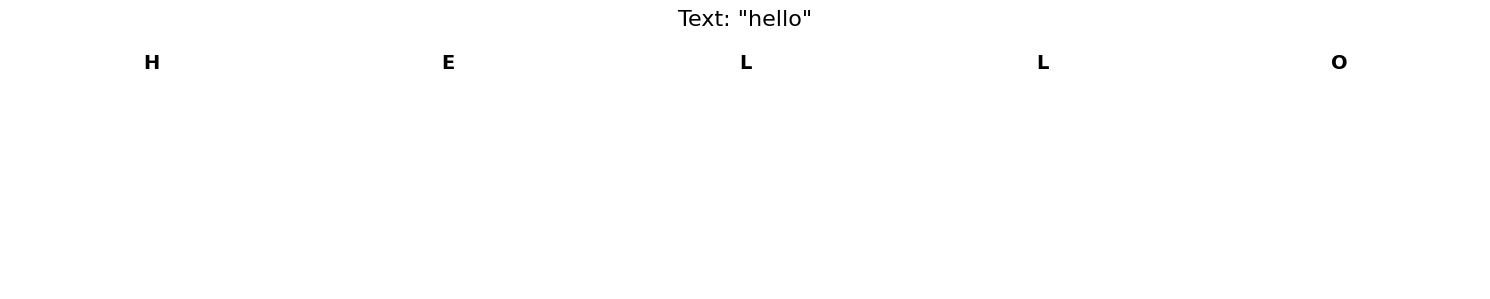

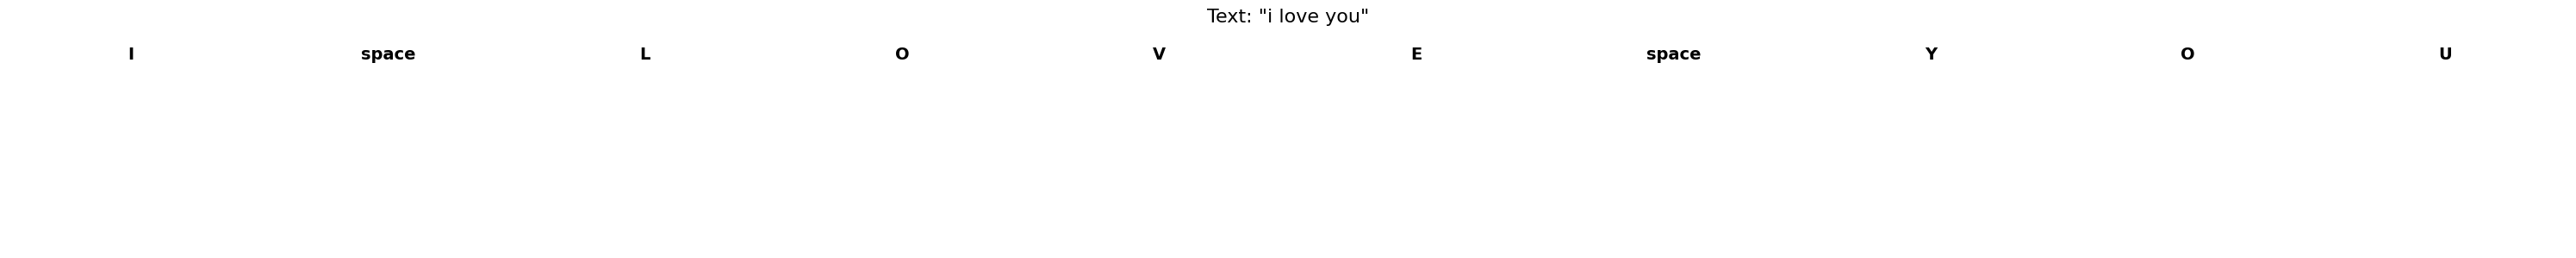

['I', 'space', 'L', 'O', 'V', 'E', 'space', 'Y', 'O', 'U']

In [25]:
# Type text, see the sign images
def text_to_sign(text):
    text = text.lower().strip()
    char_map = {c: c.upper() for c in 'abcdefghijklmnopqrstuvwxyz'}
    char_map[' '] = 'space'

    sequence = [char_map.get(c, c) for c in text if c in char_map or c.isdigit()]

    fig, axes = plt.subplots(1, len(sequence), figsize=(len(sequence)*3, 3))
    if len(sequence) == 1: axes = [axes]

    fig.suptitle(f'Text: "{text}"', fontsize=16)

    for i, char in enumerate(sequence):
        # Find image for this sign
        char_dir = os.path.join(DATASET_DIR, char)
        if os.path.exists(char_dir):
            imgs = [f for f in os.listdir(char_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            if imgs:
                img = cv2.cvtColor(cv2.imread(os.path.join(char_dir, imgs[0])), cv2.COLOR_BGR2RGB)
                axes[i].imshow(img)
        axes[i].set_title(char, fontsize=14, fontweight='bold')
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()
    return sequence

# Try it!
text_to_sign("HELLO")
text_to_sign("I LOVE YOU")

In [ ]:
# Run this INSTEAD of training next time
# !cp -r /content/drive/MyDrive/bridge_backup/models /content/

# Load saved model
loaded_model = keras.models.load_model('models/bridge_final_model.keras')
with open('models/class_names.pkl', 'rb') as f:
    loaded_classes = pickle.load(f)

print(f"✓ Loaded model with {len(loaded_classes)} classes")
print(f"Classes: {loaded_classes[:10]}...")

# Predict any image
def predict_image(image_path):
    img = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)
    img_r = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img_n = img_r.astype(np.float32) / 127.5 - 1.0
    p = loaded_model.predict(np.expand_dims(img_n, 0), verbose=0)
    idx = np.argmax(p[0])
    print(f"Predicted: {loaded_classes[idx]} ({p[0][idx]*100:.1f}%)")
    plt.imshow(img); plt.title(loaded_classes[idx]); plt.axis('off'); plt.show()

# Example: predict a test image
# predict_image('/content/asl_dataset/A/hand1_a_bot_seg_1_cropped.jpeg')

In [26]:
!pip install -q ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 26.9 MB/s eta 0:00:00


In [27]:
import os, pickle, cv2, numpy as np, tensorflow as tf
from tensorflow import keras
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import display, clear_output, Javascript, HTML
import ipywidgets as widgets
from base64 import b64decode
import io
import threading
import time

In [28]:
# Load model (adjust path if needed)
model = keras.models.load_model('models/bridge_final_model.keras')
with open('models/class_names.pkl', 'rb') as f:
    classes = pickle.load(f)

idx_to_class = {i: c for i, c in enumerate(classes)}
class_to_idx = {c: i for i, c in enumerate(classes)}
IMG_SIZE = 224

print(f"✓ Loaded model with {len(classes)} classes")
print(f"Classes: {classes[:10]}...")

✓ Loaded model with 37 classes
Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']...


In [62]:
class TextToSignAnimator:
    def __init__(self, dataset_dir='/content/asl_dataset', fps=2):
        self.dataset_dir = dataset_dir
        self.fps = fps
        self.img_cache = {}

        # Map to LOWERCASE folder names as they exist in dataset
        self.char_map = {}
        for c in '0123456789':
            self.char_map[c] = c  # Numbers stay as-is
        for c in 'abcdefghijklmnopqrstuvwxyz':
            self.char_map[c] = c  # Letters stay lowercase!
        self.char_map[' '] = 'space'

    def get_image(self, char):
        if char in self.img_cache:
            return self.img_cache[char]

        folder = os.path.join(self.dataset_dir, char)
        print(f"  Looking for: {folder}")  # Debug

        if not os.path.exists(folder):
            print(f"  ❌ Folder not found: {folder}")
            return None

        files = [f for f in os.listdir(folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if not files:
            print(f"  ❌ No images in: {folder}")
            return None

        img_path = os.path.join(folder, files[0])
        img = cv2.imread(img_path)
        if img is None:
            print(f"  ❌ Failed to load: {img_path}")
            return None

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224, 224))
        self.img_cache[char] = img
        print(f"  ✅ Loaded: {char}")
        return img

    def text_to_sequence(self, text):
        text = text.lower().strip()
        sequence = []
        for char in text:
            if char in self.char_map:
                sequence.append(self.char_map[char])
        return sequence

    def animate(self, text):
        """Animation using Output widget."""
        sequence = self.text_to_sequence(text)
        if not sequence:
            print("❌ No valid characters!")
            return

        print(f"Sequence: {' → '.join(sequence)}")

        # Preload all images
        images = []
        valid_chars = []
        for c in sequence:
            print(f"Loading '{c}'...")
            img = self.get_image(c)
            if img is not None:
                images.append(img)
                valid_chars.append(c)

        if not images:
            print("❌ No images loaded!")
            return

        print(f"✅ Loaded {len(images)} images")

        # Create output widget
        output = widgets.Output()
        progress = widgets.Label(value="Starting...")
        display(widgets.VBox([progress, output]))

        # Show each frame
        for i, (img, char) in enumerate(zip(images, valid_chars)):
            with output:
                clear_output(wait=True)

                fig, ax = plt.subplots(figsize=(5, 5))
                ax.imshow(img)
                ax.set_title(f'{char.upper()} ({i+1}/{len(valid_chars)})', fontsize=16, fontweight='bold', pad=20)
                ax.axis('off')
                plt.tight_layout()
                plt.show()

                time.sleep(0.2)  # Let it render

            progress.value = f"Showing: {char.upper()} ({i+1}/{len(valid_chars)})"
            time.sleep(1.0 / self.fps)

        progress.value = f"✅ Done: {text.upper()}"

    def show_grid(self, text, cols=5):
        sequence = self.text_to_sequence(text)
        if not sequence:
            return

        images = []
        valid_chars = []
        for c in sequence:
            img = self.get_image(c)
            if img is not None:
                images.append(img)
                valid_chars.append(c)

        rows = (len(valid_chars) + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(cols*2.5, rows*2.5))
        fig.suptitle(f'Text: "{text}"', fontsize=16, fontweight='bold')

        if rows == 1:
            axes = np.array([axes])
        axes = axes.flatten()

        for i, (img, char) in enumerate(zip(images, valid_chars)):
            axes[i].imshow(img)
            axes[i].set_title(char.upper(), fontsize=12, fontweight='bold')
            axes[i].axis('off')

        for i in range(len(valid_chars), len(axes)):
            axes[i].axis('off')

        plt.tight_layout()
        plt.show()

# Re-initialize with fixed version
animator = TextToSignAnimator(fps=1)

In [63]:
animator.animate("ABC")

Sequence: a → b → c
Loading 'a'...
  Looking for: /content/asl_dataset/a
  ✅ Loaded: a
Loading 'b'...
  Looking for: /content/asl_dataset/b
  ✅ Loaded: b
Loading 'c'...
  Looking for: /content/asl_dataset/c
  ✅ Loaded: c
✅ Loaded 3 images


In [61]:
# DEBUG: Check what's actually in the dataset
import os

dataset_dir = '/content/asl_dataset'

print("="*50)
print("DATASET DIAGNOSTIC")
print("="*50)
print(f"Dataset exists: {os.path.exists(dataset_dir)}")

if os.path.exists(dataset_dir):
    items = sorted(os.listdir(dataset_dir))
    print(f"All items: {items}")
    print(f"Total items: {len(items)}")

    # Check first few folders
    folders = [d for d in items if os.path.isdir(os.path.join(dataset_dir, d))]
    print(f"\nFolders: {folders[:10]}")

    # Check one folder in detail
    if folders:
        test_folder = folders[0]
        test_path = os.path.join(dataset_dir, test_folder)
        files = os.listdir(test_path)
        print(f"\nInside '{test_folder}': {files[:5]}")

        # Try to load one image
        img_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if img_files:
            img_path = os.path.join(test_path, img_files[0])
            img = cv2.imread(img_path)
            print(f"\nImage path: {img_path}")
            print(f"Image loaded: {img is not None}")
            if img is not None:
                print(f"Image shape: {img.shape}")

# Check what our animator expects
print("\n" + "="*50)
print("ANIMATOR EXPECTS")
print("="*50)
animator = TextToSignAnimator()
print(f"Char map: {animator.char_map}")
print(f"Dataset dir: {animator.dataset_dir}")

# Test loading 'A' manually
print("\nTesting 'A':")
folder_a = os.path.join(dataset_dir, 'A')
print(f"Folder exists: {os.path.exists(folder_a)}")
if os.path.exists(folder_a):
    files = os.listdir(folder_a)
    print(f"Files: {files[:5]}")
    img_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    print(f"Image files: {img_files[:5]}")
    if img_files:
        img = cv2.imread(os.path.join(folder_a, img_files[0]))
        print(f"Load success: {img is not None}")

DATASET DIAGNOSTIC
Dataset exists: True
All items: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'asl_dataset', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Total items: 37

Folders: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

Inside '0': ['hand2_0_top_seg_3_cropped.jpeg', 'hand1_0_left_seg_1_cropped.jpeg', 'hand4_0_bot_seg_4_cropped.jpeg', 'hand1_0_dif_seg_2_cropped.jpeg', 'hand3_0_dif_seg_5_cropped.jpeg']

Image path: /content/asl_dataset/0/hand2_0_top_seg_3_cropped.jpeg
Image loaded: True
Image shape: (400, 400, 3)

ANIMATOR EXPECTS
Char map: {'0': '0', '1': '1', '2': '2', '3': '3', '4': '4', '5': '5', '6': '6', '7': '7', '8': '8', '9': '9', 'a': 'A', 'b': 'B', 'c': 'C', 'd': 'D', 'e': 'E', 'f': 'F', 'g': 'G', 'h': 'H', 'i': 'I', 'j': 'J', 'k': 'K', 'l': 'L', 'm': 'M', 'n': 'N', 'o': 'O', 'p': 'P', 'q': 'Q', 'r': 'R', 's': 'S', 't': 'T', 'u': 'U', 'v': 'V', 'w': 'W', 'x': 'X', 'y': 'Y',

In [43]:
# Test 1: Check dataset path exists
print("Dataset exists:", os.path.exists('/content/asl_dataset'))
print("Classes:", sorted(os.listdir('/content/asl_dataset'))[:10])

# Test 2: Load a single image manually
test_folder = os.path.join('/content/asl_dataset', 'A')
if os.path.exists(test_folder):
    files = [f for f in os.listdir(test_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    print(f"A folder has {len(files)} images")
    if files:
        test_path = os.path.join(test_folder, files[0])
        img = cv2.imread(test_path)
        print(f"Image loaded: {img is not None}")
        if img is not None:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.figure(figsize=(3, 3))
            plt.imshow(img_rgb)
            plt.title("Test: Letter A")
            plt.axis('off')
            plt.show()

# Test 3: Animate simple text
animator.animate("ABC")

✓ Animation complete!


In [44]:
def take_photo(quality=0.8):
    """Capture photo from webcam in Colab."""
    js = Javascript('''
        async function takePhoto(quality) {
            const div = document.createElement('div');
            const capture = document.createElement('button');
            capture.textContent = '📸 Capture Sign';
            capture.style.cssText = 'font-size:20px;padding:15px 30px;margin:20px;cursor:pointer;background:#ff4444;color:white;border:none;border-radius:10px;';
            div.appendChild(capture);

            const video = document.createElement('video');
            video.style.display = 'block';
            video.style.width = '400px';
            video.style.borderRadius = '10px';
            const stream = await navigator.mediaDevices.getUserMedia({video: true});

            document.body.appendChild(div);
            div.appendChild(video);
            video.srcObject = stream;
            await video.play();

            google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

            await new Promise((resolve) => capture.onclick = resolve);

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            canvas.getContext('2d').drawImage(video, 0, 0);
            stream.getVideoTracks()[0].stop();
            div.remove();

            return canvas.toDataURL('image/jpeg', quality);
        }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    return Image.open(io.BytesIO(binary))

def predict_image(pil_image):
    """Predict sign from PIL image."""
    img = np.array(pil_image)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype(np.float32) / 127.5 - 1.0
    img = np.expand_dims(img, 0)

    pred = model.predict(img, verbose=0)
    idx = np.argmax(pred[0])
    confidence = pred[0][idx]

    return idx_to_class[idx], float(confidence), pred[0]

def capture_and_predict():
    """Full pipeline: capture + predict."""
    print("📷 Click the red button to capture your sign...")

    try:
        img = take_photo()
    except Exception as e:
        print(f"❌ Camera error: {e}")
        return None, 0

    # Show captured image
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Captured Image')
    plt.show()

    # Predict
    sign, conf, all_preds = predict_image(img)

    print(f"\n{'='*50}")
    print(f"🤟 PREDICTED SIGN: {sign}")
    print(f"📊 Confidence: {conf*100:.1f}%")
    print(f"{'='*50}")

    # Top 5
    top5 = np.argsort(all_preds)[-5:][::-1]
    print("\nTop 5 predictions:")
    for i in top5:
        bar = '█' * int(all_preds[i] * 20)
        print(f"  {idx_to_class[i]:>10} | {bar} {all_preds[i]*100:.1f}%")

    return sign, conf

In [64]:
# Create tabs
tab = widgets.Tab()

# ===== TAB 1: Text → Sign =====
text_input = widgets.Text(
    value='HELLO',
    placeholder='Type something...',
    description='Text:',
    layout=widgets.Layout(width='400px')
)

speed_slider = widgets.IntSlider(value=2, min=1, max=5, step=1, description='Speed:')

animate_btn = widgets.Button(
    description='▶️ Animate',
    button_style='success',
    layout=widgets.Layout(width='150px')
)

grid_btn = widgets.Button(
    description='📋 Grid',
    button_style='info',
    layout=widgets.Layout(width='150px')
)

text_output = widgets.Output()

def on_animate(b):
    with text_output:
        clear_output(wait=True)
        animator.fps = speed_slider.value
        animator.animate(text_input.value)

def on_grid(b):
    with text_output:
        clear_output(wait=True)
        animator.show_grid(text_input.value)

animate_btn.on_click(on_animate)
grid_btn.on_click(on_grid)

tab1 = widgets.VBox([
    widgets.HTML("<h2>📝 Text → Sign Language</h2>"),
    widgets.HBox([text_input, speed_slider]),
    widgets.HBox([animate_btn, grid_btn]),
    text_output
])

# ===== TAB 2: Camera → Text =====
cam_btn = widgets.Button(
    description='📷 Capture & Predict',
    button_style='danger',
    layout=widgets.Layout(width='200px', height='50px')
)

cam_output = widgets.Output()

def on_camera(b):
    with cam_output:
        clear_output(wait=True)
        capture_and_predict()

cam_btn.on_click(on_camera)

tab2 = widgets.VBox([
    widgets.HTML("<h2>📸 Sign to Text (Webcam)</h2>"),
    widgets.HTML("<p>Click below, then click the 📸 button in the live feed</p>"),
    cam_btn,
    cam_output
])

# ===== TAB 3: File Upload =====
uploader = widgets.FileUpload(accept='image/*', multiple=False)

file_output = widgets.Output()

def on_upload(change):
    with file_output:
        clear_output(wait=True)
        if not uploader.value:
            return

        # Handle different widget versions
        uploaded = list(uploader.value.values())[0] if isinstance(uploader.value, dict) else uploader.value[0]
        content = uploaded['content'] if isinstance(uploaded, dict) else uploaded

        img = Image.open(io.BytesIO(content))

        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.axis('off')
        plt.title('Uploaded')
        plt.show()

        sign, conf, all_preds = predict_image(img)
        print(f"\n🤟 Predicted: {sign} ({conf*100:.1f}%)")

uploader.observe(on_upload, names='value')

tab3 = widgets.VBox([
    widgets.HTML("<h2>📁 Upload Image</h2>"),
    uploader,
    file_output
])

tab.children = [tab1, tab2, tab3]
tab.set_title(0, '📝 Text → Sign')
tab.set_title(1, '📸 Sign → Text')
tab.set_title(2, '📁 Upload')

display(widgets.HTML("<h1 style='color:#2E86AB'>🌉 BRIDGE - Sign Language Translator</h1>"))
display(tab)

HTML(value="<h1 style='color:#2E86AB'>🌉 BRIDGE - Sign Language Translator</h1>")

DATASET CHECK
Path exists: True
Contents: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']...

First folder: 7
Images in folder: 70
cv2.imread success: True


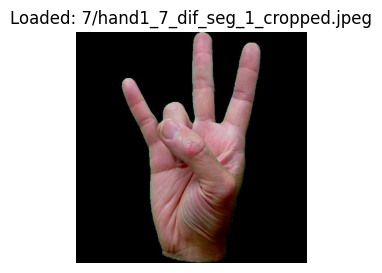

✅ Dataset loads correctly!


In [39]:
# CRITICAL TEST - Run this first
import os
dataset_path = '/content/asl_dataset'

print("="*50)
print("DATASET CHECK")
print("="*50)
print(f"Path exists: {os.path.exists(dataset_path)}")

if os.path.exists(dataset_path):
    items = os.listdir(dataset_path)
    print(f"Contents: {sorted(items)[:10]}...")

    # Try loading first image from first folder
    first_folder = [d for d in items if os.path.isdir(os.path.join(dataset_path, d))][0]
    first_path = os.path.join(dataset_path, first_folder)
    images = [f for f in os.listdir(first_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

    print(f"\nFirst folder: {first_folder}")
    print(f"Images in folder: {len(images)}")

    if images:
        img_path = os.path.join(first_path, images[0])
        img = cv2.imread(img_path)
        print(f"cv2.imread success: {img is not None}")

        if img is not None:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.figure(figsize=(3, 3))
            plt.imshow(img_rgb)
            plt.title(f"Loaded: {first_folder}/{images[0]}")
            plt.axis('off')
            plt.show()
            print("✅ Dataset loads correctly!")

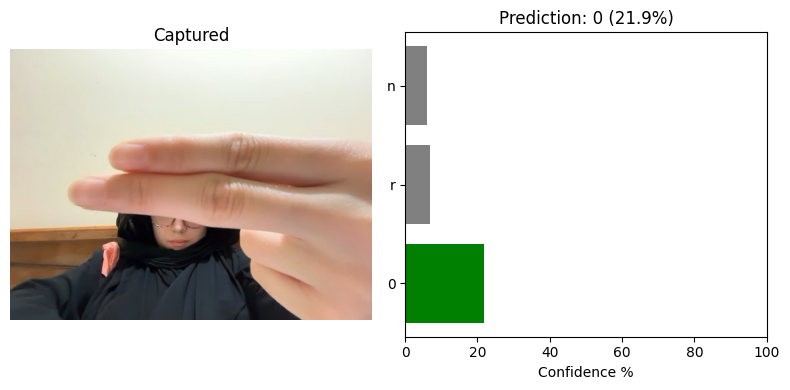


🤟 SIGN: 0
📊 Confidence: 21.9%
🔍 Top 3: 0: 21.9% | r: 7.0% | n: 5.9%

⏱️ Next capture in 5 seconds... (click ⏹️ Stop to end)


In [67]:
from IPython.display import display, Javascript, HTML, clear_output
from base64 import b64decode
import io
from PIL import Image
import time
import threading

# JavaScript for webcam capture
def get_webcam_html():
    return """
    <div style="border: 2px solid #333; padding: 10px; border-radius: 10px; background: #f0f0f0;">
        <video id="video" width="400" height="300" autoplay style="border-radius: 8px; background: #000;"></video>
        <br><br>
        <button id="capture" style="font-size: 18px; padding: 12px 30px; background: #ff4444; color: white; border: none; border-radius: 8px; cursor: pointer;">
            📸 Capture & Predict
        </button>
        <button id="continuous" style="font-size: 18px; padding: 12px 30px; background: #44aa44; color: white; border: none; border-radius: 8px; cursor: pointer; margin-left: 10px;">
            ▶️ Auto (5 sec)
        </button>
        <div id="result" style="margin-top: 15px; font-size: 20px; font-weight: bold; color: #333;"></div>
    </div>
    <script>
        const video = document.getElementById('video');
        const captureBtn = document.getElementById('capture');
        const continuousBtn = document.getElementById('continuous');
        const resultDiv = document.getElementById('result');
        let stream = null;
        let autoInterval = null;

        // Start webcam
        async function startCamera() {
            try {
                stream = await navigator.mediaDevices.getUserMedia({ video: true });
                video.srcObject = stream;
                resultDiv.innerHTML = "✅ Camera active! Click a button below.";
            } catch (err) {
                resultDiv.innerHTML = "❌ Camera error: " + err.message;
            }
        }

        // Capture frame
        function captureFrame() {
            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;
            const ctx = canvas.getContext('2d');
            ctx.drawImage(video, 0, 0);
            return canvas.toDataURL('image/jpeg', 0.9);
        }

        // Send to Python
        function sendToPython(imageData, mode) {
            google.colab.kernel.invokeFunction('notebook.predict_sign', [imageData, mode], {});
        }

        captureBtn.onclick = () => {
            resultDiv.innerHTML = "⏳ Processing...";
            const imgData = captureFrame();
            sendToPython(imgData, 'single');
        };

        continuousBtn.onclick = () => {
            if (autoInterval) {
                clearInterval(autoInterval);
                autoInterval = null;
                continuousBtn.innerHTML = "▶️ Auto (5 sec)";
                continuousBtn.style.background = "#44aa44";
                resultDiv.innerHTML = "⏹️ Stopped";
            } else {
                resultDiv.innerHTML = "🔴 Auto mode: Capturing every 5 seconds...";
                continuousBtn.innerHTML = "⏹️ Stop";
                continuousBtn.style.background = "#aa4444";
                const imgData = captureFrame();
                sendToPython(imgData, 'auto');
                autoInterval = setInterval(() => {
                    const imgData = captureFrame();
                    sendToPython(imgData, 'auto');
                }, 5000);
            }
        };

        startCamera();
    </script>
    """

# Python callback function
from google.colab import output

def predict_sign_from_js(image_data, mode):
    """Called from JavaScript when user clicks capture."""
    try:
        # Decode base64 image
        binary = b64decode(image_data.split(',')[1])
        img = Image.open(io.BytesIO(binary))

        # Convert to numpy and predict
        img_array = np.array(img)
        img_resized = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
        img_norm = img_resized.astype(np.float32) / 127.5 - 1.0
        img_batch = np.expand_dims(img_norm, 0)

        # Predict
        pred = model.predict(img_batch, verbose=0)
        idx = np.argmax(pred[0])
        sign = idx_to_class[idx]
        confidence = float(pred[0][idx])

        # Get top 3
        top3 = np.argsort(pred[0])[-3:][::-1]
        top3_text = " | ".join([f"{idx_to_class[i]}: {pred[0][i]*100:.1f}%" for i in top3])

        # Display result
        clear_output(wait=True)

        # Show captured image with prediction
        plt.figure(figsize=(8, 4))

        plt.subplot(1, 2, 1)
        plt.imshow(img_array)
        plt.title("Captured")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        # Show confidence bar
        colors = ['green' if i == idx else 'gray' for i in top3]
        plt.barh(range(len(top3)), [pred[0][i]*100 for i in top3], color=colors)
        plt.yticks(range(len(top3)), [idx_to_class[i] for i in top3])
        plt.xlabel('Confidence %')
        plt.title(f'Prediction: {sign} ({confidence*100:.1f}%)')
        plt.xlim(0, 100)

        plt.tight_layout()
        plt.show()

        print(f"\n🤟 SIGN: {sign}")
        print(f"📊 Confidence: {confidence*100:.1f}%")
        print(f"🔍 Top 3: {top3_text}")

        if mode == 'auto':
            print(f"\n⏱️ Next capture in 5 seconds... (click ⏹️ Stop to end)")

    except Exception as e:
        print(f"❌ Error: {e}")
        import traceback
        traceback.print_exc()

# Register the callback
output.register_callback('notebook.predict_sign', predict_sign_from_js)

# Display the webcam interface
display(HTML(get_webcam_html()))

In [69]:
from google.colab import files
import os

# Download model + classes
if os.path.exists('models/bridge_final_model.keras'):
    files.download('models/bridge_final_model.keras')
    files.download('models/class_names.pkl')
    print("✅ Model files downloaded!")
else:
    print("❌ Model not found - did training finish?")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Model files downloaded!


In [70]:
# Zip dataset for re-upload
!cd /content && zip -r asl_dataset_small.zip asl_dataset/ -x "*.DS_Store"
files.download('/content/asl_dataset_small.zip')

Streaming output truncated to the last 5000 lines.
  adding: asl_dataset/3/hand2_3_bot_seg_1_cropped.jpeg (deflated 10%)
  adding: asl_dataset/3/hand1_3_left_seg_3_cropped.jpeg (deflated 9%)
  adding: asl_dataset/3/hand5_3_bot_seg_2_cropped.jpeg (deflated 9%)
  adding: asl_dataset/3/hand1_3_top_seg_1_cropped.jpeg (deflated 9%)
  adding: asl_dataset/3/hand1_3_right_seg_3_cropped.jpeg (deflated 9%)
  adding: asl_dataset/3/hand1_3_right_seg_2_cropped.jpeg (deflated 9%)
  adding: asl_dataset/3/hand2_3_left_seg_1_cropped.jpeg (deflated 10%)
  adding: asl_dataset/3/hand2_3_bot_seg_2_cropped.jpeg (deflated 10%)
  adding: asl_dataset/3/hand2_3_right_seg_1_cropped.jpeg (deflated 10%)
  adding: asl_dataset/3/hand2_3_left_seg_2_cropped.jpeg (deflated 10%)
  adding: asl_dataset/3/hand2_3_top_seg_5_cropped.jpeg (deflated 10%)
  adding: asl_dataset/3/hand4_3_bot_seg_4_cropped.jpeg (deflated 8%)
  adding: asl_dataset/3/hand3_3_dif_seg_4_cropped.jpeg (deflated 10%)
  adding: asl_dataset/3/hand1_3_bot_

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# BRIDGE - QUICK START (No Google Drive)
# ============================================================

# 1. Upload these files via Files panel first:
#    - bridge_final_model.keras
#    - class_names.pkl
#    - asl_dataset_small.zip (optional, or re-download from Kaggle)

import os
import zipfile

# 2. Extract dataset if uploaded
if os.path.exists('/content/asl_dataset_small.zip'):
    with zipfile.ZipFile('/content/asl_dataset_small.zip', 'r') as z:
        z.extractall('/content/')
    print("✅ Dataset extracted")

# 3. Load model
import pickle
import tensorflow as tf
from tensorflow import keras
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

model = keras.models.load_model('/content/models/bridge_final_model.keras')
with open('/content/models/class_names.pkl', 'rb') as f:
    classes = pickle.load(f)

idx_to_class = {i: c for i, c in enumerate(classes)}
class_to_idx = {c: i for i, c in enumerate(classes)}
IMG_SIZE = 224

print(f"🚀 READY! {len(classes)} classes loaded")

# 4. Your prediction function
def predict_image(img):
    if isinstance(img, Image.Image):
        img = np.array(img)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype(np.float32) / 127.5 - 1.0
    img = np.expand_dims(img, 0)
    pred = model.predict(img, verbose=0)
    idx = np.argmax(pred[0])
    return idx_to_class[idx], float(pred[0][idx]), pred[0]

# 5. Your animator (copy from working version)
class TextToSignAnimator:
    def __init__(self, dataset_dir='/content/asl_dataset', fps=2):
        self.dataset_dir = dataset_dir
        self.fps = fps
        self.img_cache = {}
        self.char_map = {}
        for c in '0123456789': self.char_map[c] = c
        for c in 'abcdefghijklmnopqrstuvwxyz': self.char_map[c] = c
        self.char_map[' '] = 'space'

    def get_image(self, char):
        if char in self.img_cache: return self.img_cache[char]
        folder = os.path.join(self.dataset_dir, char)
        if not os.path.exists(folder): return None
        files = [f for f in os.listdir(folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if not files: return None
        img = cv2.imread(os.path.join(folder, files[0]))
        if img is None: return None
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224, 224))
        self.img_cache[char] = img
        return img

    def text_to_sequence(self, text):
        text = text.lower().strip()
        return [self.char_map[c] for c in text if c in self.char_map]

    def show_grid(self, text, cols=5):
        sequence = self.text_to_sequence(text)
        images = [self.get_image(c) for c in sequence]
        images = [(img, c) for img, c in zip(images, sequence) if img is not None]
        if not images: return
        rows = (len(images) + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(cols*2.5, rows*2.5))
        fig.suptitle(f'Text: "{text}"', fontsize=16, fontweight='bold')
        if rows == 1: axes = np.array([axes])
        axes = axes.flatten()
        for i, (img, char) in enumerate(images):
            axes[i].imshow(img); axes[i].set_title(char.upper(), fontsize=12, fontweight='bold'); axes[i].axis('off')
        for i in range(len(images), len(axes)): axes[i].axis('off')
        plt.tight_layout(); plt.show()

animator = TextToSignAnimator()
print("✅ Animator ready")